# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

In [2]:
## Helper function to inspect quickly the object by printing the methods
def class_methods(obj):
    methods = []
    for name in dir(obj):
        try:
            attr = getattr(obj, name)
            if callable(attr) and not name.startswith("__"):
                methods.append(name)
        except Exception:
            pass
    return methods


def print_obj_summary(obj,str = "obj"):
    print(f"\n Info about ",str," -> \n",
        "Class : ", obj,"\n",
        "Obj_attributess : ", vars(obj),"\n"
        "Relevant methods : ",class_methods(obj),"\n")
    


In [3]:
import gymnasium as gym


In [ ]:
# Instantiate a rendering and a non-rendering environment.
env_render = gym.make('CartPole-v1', render_mode = 'human')
env = gym.make('CartPole-v1',render_mode = None)
env_render = gym.make('CartPole-v1')
observation , info = env.reset()
print(f"Example of obseravation : ", observation ,"\n Info :",info)
## Observation is a ndarray


print_obj_summary(env,"env")
print_obj_summary(env.action_space,"action space") ## we can move 2 directions
print_obj_summary(env.observation_space,"observation space") ## Observation space is a Discrete(2)

## Trying to sample from both spaces
print(f"sample from observation space ",env.observation_space.sample())
print(f"sample from action space ",env.action_space.sample())

## Trying to perform a step , ( Already called .reset() )
action = env.action_space.sample()
observation , reward , terminated , truncated , info  = env.step(action)
print("Reward obtaing in a single step is : ",reward,"\n")

## Finally simulationg one episode

terminated = False
env.reset()
step = 0
while not (terminated or truncated):
    action = env.action_space.sample()
    observation , reward , truncated , terminated , info  = env.step(action)
    step += 1
    print(f"Reward at step ",step,": ",reward)
    print(f"Info at step ",step,": ",info,"\n")
print("episode lasted for ",step," steps")

Example of obseravation :  [-0.01731525 -0.01248053  0.00820995  0.04596925] 
 Info : {}

 Info about  env  -> 
 Class :  <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>> 
 Obj_attributess :  {'_saved_kwargs': {'max_episode_steps': 500}, 'env': <OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>, '_action_space': None, '_observation_space': None, '_metadata': None, '_cached_spec': EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={'render_mode': None}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv'), '_max_episode_steps': 500, '_elapsed_steps': 0} 
Relevant methods :  ['class_name', 'close', 'get_wrapper_attr', 'has_wrapper_attr', 'render', 'reset', 'set_wrapper_attr', 'step', 'wrapper_spe

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

In [4]:
# Your code here. You should be able to train an agent to solve Cartpole. This will be our starting point.
import numpy as np
from src.train import train
from src.policynet import PolicyNet
from src.device import device

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

**First** we define the seed , the CartPole env. and where we want to save the weights of our policy net

In [5]:
## seed = 1234  --w.o baseline with this seed i obtained a plateux of 9 on running reward
seed = 42
w_path = f"weights/{seed}"
v_path = f"videos/{seed}"
n_path = f"numeric/{seed}"
lr = 1e-3
num_episodes = 1000

We run our **traing loop** and collect the result including the metrics requested.

In [6]:
import os
def create_folders(*dirs):
    for dir in dirs:
        os.makedirs(dir,exist_ok=True)

In [6]:
# Running original implementation with baseline (i.e. standardize returns)

env = gym.make("CartPole-v1")
policy = PolicyNet(env).to(device)

baseline = "mean"
w_p_bs_mean = f"{w_path}/{baseline}/lr_{lr}"
v_p_bs_mean = f"{v_path}/{baseline}/lr_{lr}"
n_p_bs_mean = f"{n_path}/{baseline}/lr_{lr}"

create_folders(w_p_bs_mean,v_p_bs_mean,n_p_bs_mean)


## since I want to plot the results together I have to name differently these 3 following 
## variable otherwise I think the notebook will perform something I cannot control
## rr --> running reward , er --> eval_rewards , el --> eval_lenght

rr_bs_mean,er_bs_mean,el_bs_mean = train(
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        baseline = baseline,
        w_path = w_p_bs_mean,
        v_path = v_p_bs_mean,
        n_path = n_p_bs_mean,
        num_episodes = 1000
        )


started trainig with lr = 0.001
Applying baseline
Running reward: 0.6124
Running reward: 32.0321
Running reward: 44.6642
Running reward: 70.4465
Running reward: 81.3602
Running reward: 89.5582
Running reward: 91.1761
Running reward: 96.2058
Running reward: 97.0433
Running reward: 98.3594


/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/andrea/dev/DLA/3_DRL/videos/42/mean/lr_0.001 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Now we import our plots function (useful for now and later) to plot our results and define a commodity function to ease our work

In [9]:
%matplotlib inline
from src.plot import plot_results,plot_combined_results

def plot_single_results(rr,er,el):

    plot_results(
        (np.arange(1,len(rr)+1) , rr , "# episodes" , "running reward"),
        (np.arange(1,len(er)+1) , er , "# episodes" , "eval reward"),
        (np.arange(1,len(el)+1) , el , "# episodes" , "eval lenght"),
        show = True,
        save = False
    )

def plot_multiple_results(*methods):

    ## every 'method' passed shuold be in the form of (rr, er, el, label)
    
    method_triples = []
    for (rr, er, el, label) in methods:
        triples = [
            (np.arange(1, len(rr)+1), rr, "# episodes", "running reward", label),
            (np.arange(1, len(er)+1), er, "# episodes", "eval reward",   label),
            (np.arange(1, len(el)+1), el, "# episodes", "eval length",   label),
        ]
        method_triples.append(triples)

    plot_combined_results(*method_triples, show=True, save=False)




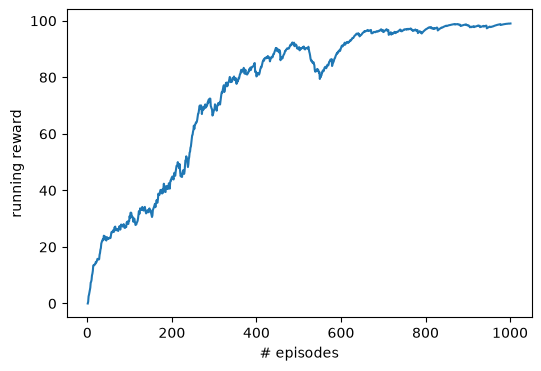

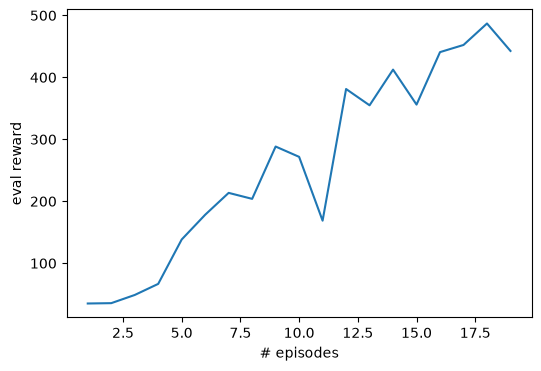

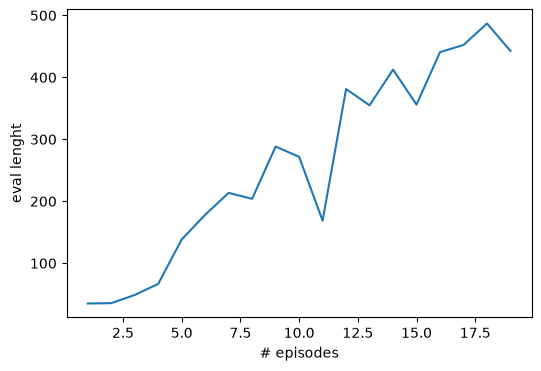

In [8]:
### Plotting the results of baseline with mean 

plot_single_results(rr_bs_mean,er_bs_mean,el_bs_mean)


-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

## Running code w.o baseline
- first with the .sum() in the loss function

In [9]:
# Running vanilla implementation w.o baseline
## rr without _bs is indicating without baseline

env = gym.make("CartPole-v1")
policy = PolicyNet(env).to(device)

baseline = "no_baseline"
loss_op = "sum"

w_p_mean = f"{w_path}/{baseline}/{loss_op}/lr_{lr}"
v_p_mean = f"{v_path}/{baseline}/{loss_op}/lr_{lr}"
n_p_mean = f"{n_path}/{baseline}/{loss_op}/lr_{lr}"

create_folders(w_p_mean,w_p_mean,n_p_mean)


rr_sum,er_sum,el_sum = train(
        loss_op = loss_op,
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        baseline = None,
        w_path = w_p_mean,
        v_path = v_p_mean,
        n_path = n_p_mean,
        num_episodes = 1000
        )

started trainig with lr = 0.001
No baseline applied
Running reward: 0.5233
Running reward: 23.2341
Running reward: 34.2412
Running reward: 63.6368
Running reward: 90.0179
Running reward: 95.4113
Running reward: 96.7078
Running reward: 94.0497
Running reward: 97.0152
Running reward: 98.1953


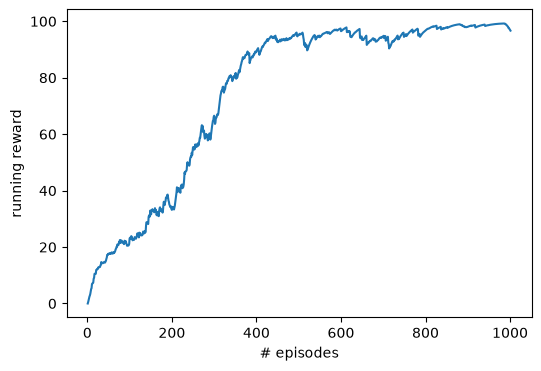

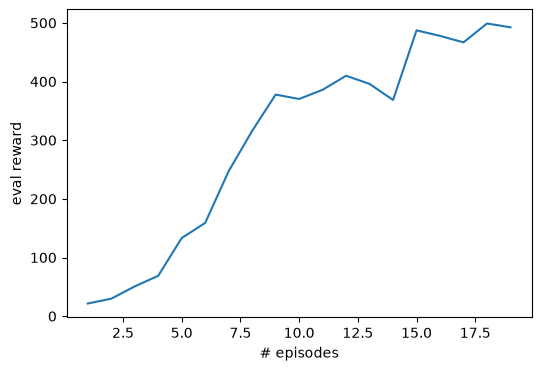

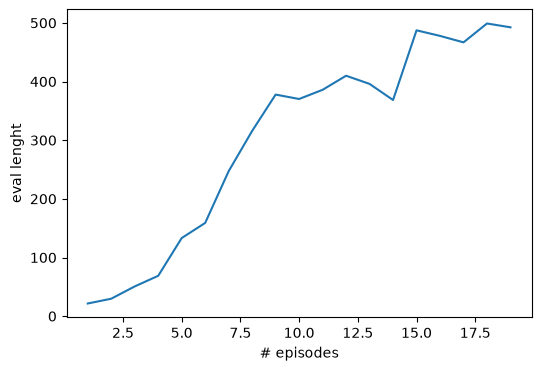

In [10]:
plot_single_results(rr_sum,er_sum,el_sum)

- now with the mean

In [ ]:
### running vanilla implementation with .mean() in the loss (I expect the training regime not to change that much)

env = gym.make("CartPole-v1")
policy = PolicyNet(env).to(device)

baseline = "no_baseline"
loss_op = "mean"

w_p_sum= f"{w_path}/{baseline}/{loss_op}/lr_{lr}"
v_p_sum = f"{v_path}/{baseline}/{loss_op}/lr_{lr}"
n_p_sum = f"{n_path}/{baseline}/{loss_op}/lr_{lr}"

create_folders(w_p_sum,v_p_sum,n_p_sum)


rr_mean,er_mean,el_mean = train(
        loss_op = loss_op,
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        baseline = None,
        w_path = w_p_sum,
        v_path = v_p_sum,
        n_path = n_p_sum,
        num_episodes = 1000
        )

started trainig with lr = 0.001
No baseline applied
Running reward: 0.5233
Running reward: 22.4857
Running reward: 21.3727
Running reward: 21.7265
Running reward: 32.7310
Running reward: 45.9489
Running reward: 67.0361
Running reward: 78.8673
Running reward: 76.6278
Running reward: 83.8942


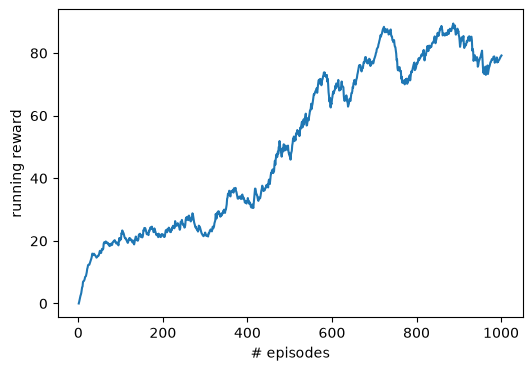

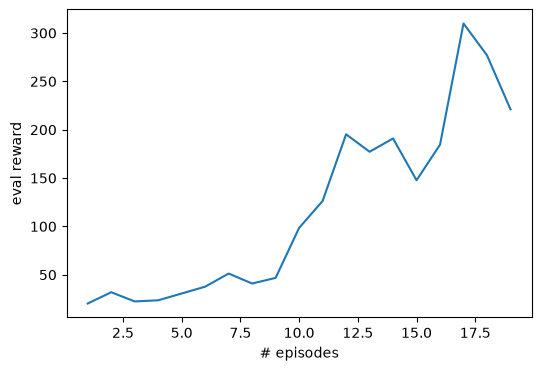

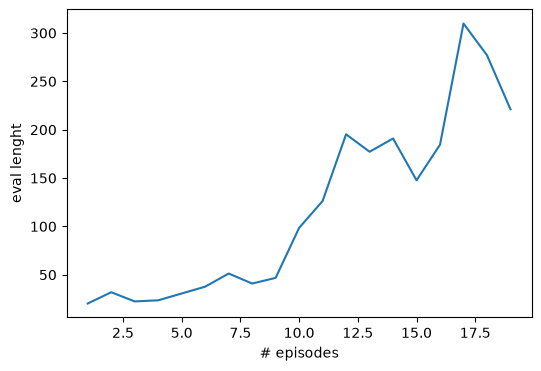

In [15]:
plot_single_results(rr_mean,er_mean,el_mean)

Now let's plot everything togheter for a comparison

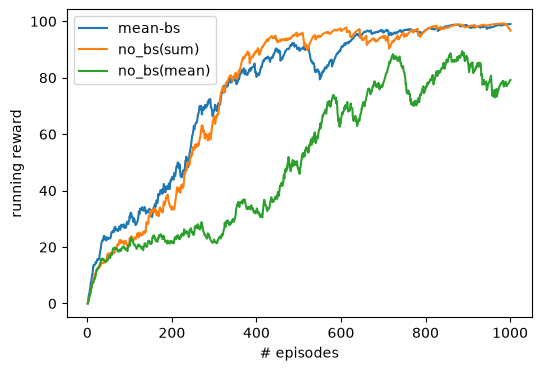

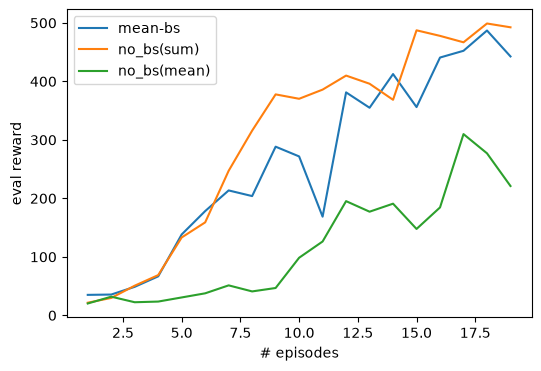

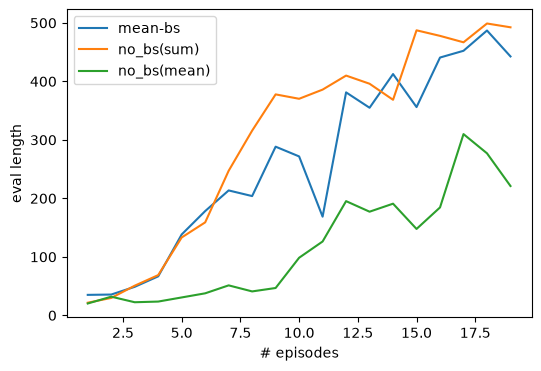

In [16]:
plot_multiple_results(  (rr_bs_mean,er_bs_mean,el_bs_mean,"mean-bs"),
                        (rr_sum,er_sum,el_sum,"no_bs(sum)"),
                        (rr_mean,er_mean,el_mean,"no_bs(mean)"))

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

In [1]:
from src.train import train

pygame 2.6.1 (SDL 2.28.4, Python 3.13.11)
Hello from the pygame community. https://www.pygame.org/contribute.html
Currently available device:  cuda


/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [7]:
from src.valuenet import ValueNet

env = gym.make("CartPole-v1")

# Spostiamo entrambe le reti sul device
policy = PolicyNet(env).to(device)
value_net = ValueNet(env).to(device)

baseline_string = "valuenet" 
loss_op = "mean"

lr_vnet = 1e-3

w_p_vnet= f"{w_path}/{baseline_string}/{loss_op}/lr_{lr}"
v_p_vnet = f"{v_path}/{baseline_string}/{loss_op}/lr_{lr}"
n_p_vnet = f"{n_path}/{baseline_string}/{loss_op}/lr_{lr}"

create_folders(w_p_vnet, v_p_vnet, n_p_vnet)

rr_vnet, er_vnet, el_vnet = train(
        loss_op = loss_op,
        env = env,
        policy = policy,
        seed = seed,
        lr = lr,
        lr_vnet = lr_vnet,
        baseline = value_net,  
        w_path = w_p_vnet,
        v_path = v_p_vnet,
        n_path = n_p_vnet,
        num_episodes = 1000
)

started trainig with lr = 0.001
Applying baseline


/home/andrea/dev/DLA/3_DRL/src/reinforce.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs_tensor = torch.tensor(torch.stack(obs), dtype=torch.float32)


Running reward: 0.5233
Running reward: 28.0239
Running reward: 34.8418
Running reward: 72.1031
Running reward: 88.6887
Running reward: 96.6711
Running reward: 98.5421
Running reward: 99.0291
Running reward: 95.2373
Running reward: 99.2478


/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/andrea/dev/DLA/3_DRL/videos/42/valuenet/mean/lr_0.001 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


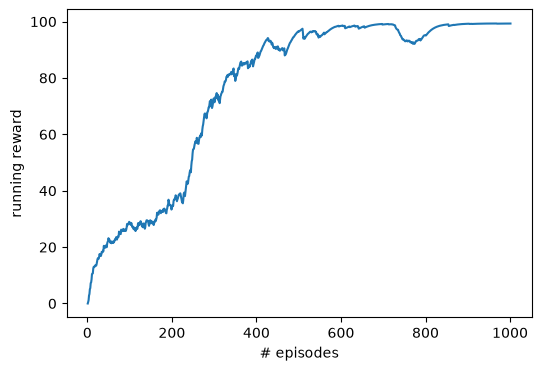

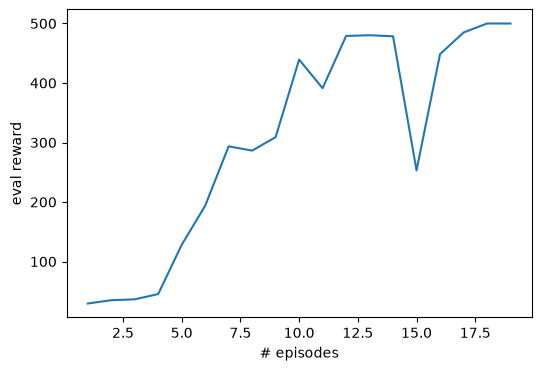

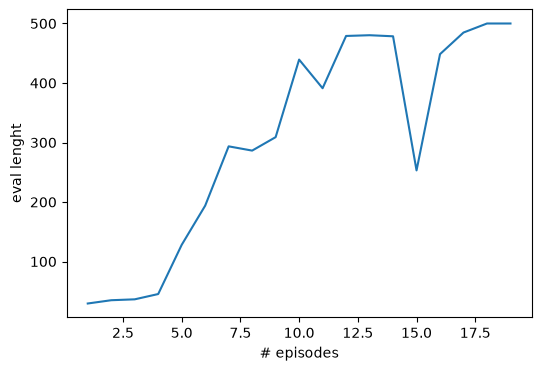

In [10]:
plot_single_results(rr_vnet,er_vnet,el_vnet)

PLotting everethying together

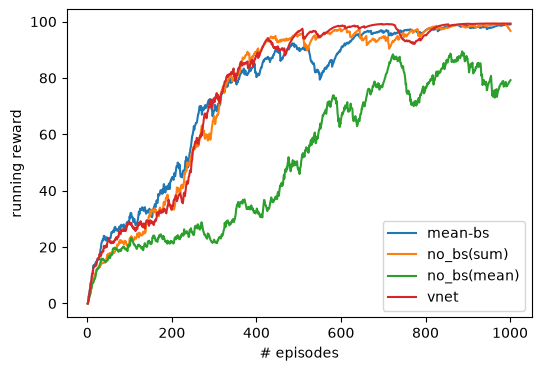

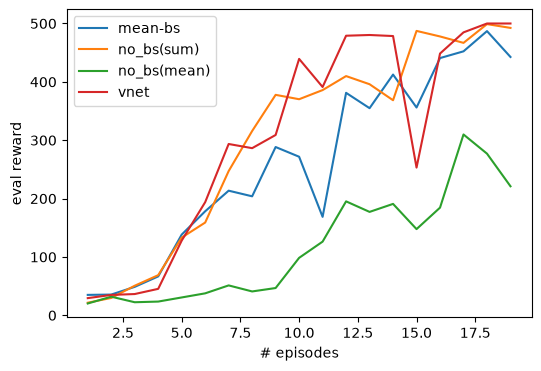

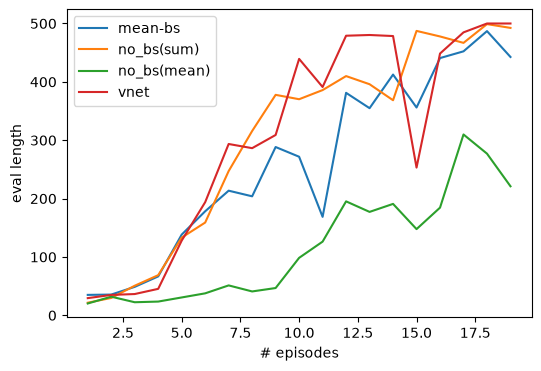

In [12]:
#### we load the data 

n_path_base = f"numeric/{seed}"
learning_rate = lr


# 1. "mean-bs"
path_mean_bs = f"{n_path_base}/mean/lr_{learning_rate}"
rr_bs_mean = np.load(f"{path_mean_bs}/running_rewards.npy")
er_bs_mean = np.load(f"{path_mean_bs}/eval_rewards.npy")
el_bs_mean = np.load(f"{path_mean_bs}/eval_lenght.npy")

# 2. Carica "no_bs(sum)" (Baseline: "no_baseline", Loss: "sum")
path_no_bs_sum = f"{n_path_base}/no_baseline/sum/lr_{learning_rate}"
rr_sum = np.load(f"{path_no_bs_sum}/running_rewards.npy")
er_sum = np.load(f"{path_no_bs_sum}/eval_rewards.npy")
el_sum = np.load(f"{path_no_bs_sum}/eval_lenght.npy")

# 3. Carica "no_bs(mean)" (Baseline: "no_baseline", Loss: "mean")
path_no_bs_mean = f"{n_path_base}/no_baseline/mean/lr_{learning_rate}"
rr_mean = np.load(f"{path_no_bs_mean}/running_rewards.npy")
er_mean = np.load(f"{path_no_bs_mean}/eval_rewards.npy")
el_mean = np.load(f"{path_no_bs_mean}/eval_lenght.npy")

# 4. Carica "vnet" (Baseline: "valuenet", Loss: "mean")
path_vnet = f"{n_path_base}/valuenet/mean/lr_{learning_rate}"
rr_vnet = np.load(f"{path_vnet}/running_rewards.npy")
er_vnet = np.load(f"{path_vnet}/eval_rewards.npy")
el_vnet = np.load(f"{path_vnet}/eval_lenght.npy")



plot_multiple_results(
    (rr_bs_mean, er_bs_mean, el_bs_mean, "mean-bs"),
    (rr_sum, er_sum, el_sum, "no_bs(sum)"),
    (rr_mean, er_mean, el_mean, "no_bs(mean)"),
    (rr_vnet, er_vnet, el_vnet, "vnet")
)


-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 

# 3 OpenAi car 

In [5]:
import gymnasium as gym
import torch
import numpy as np
from gymnasium.wrappers import GrayscaleObservation, FrameStackObservation, ResizeObservation, RecordVideo
from IPython.display import Video, display
import os

from OpenAIcar.src.models import CNNDiscreteAgent

def record_and_display_video(model_path, gym_id="CarRacing-v3"):

    env = gym.make(gym_id, continuous=False, render_mode="rgb_array")
    
    os.makedirs("videos_car", exist_ok=True)
    env = RecordVideo(
        env, 
        video_folder="videos_car", 
        name_prefix="best_run",
        episode_trigger=lambda x: True 
    )
    
    env = GrayscaleObservation(env, keep_dim=False)
    env = ResizeObservation(env, (84, 84)) 
    env = FrameStackObservation(env, 4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    obs_shape = env.observation_space.shape
    action_dim = env.action_space.n
    
    agent = CNNDiscreteAgent(obs_shape, action_dim).to(device)
    
    checkpoint = torch.load(model_path, map_location=device,weights_only=False)
    agent.load_state_dict(checkpoint['agent_state_dict'])
    agent.eval()

    obs, info = env.reset()
    
    done = False
    episodic_return = 0

    while not done:
        obs_tensor = torch.tensor(np.array([obs])).to(device)
        obs_tensor = obs_tensor.float()/255

        with torch.no_grad():
            hidden = agent.network(obs_tensor)
            
            logits = agent.actor(hidden)
            
            action = torch.argmax(logits, dim=1)

        action_np = action.cpu().numpy()[0]

        next_obs, reward, terminated, truncated, info = env.step(action_np)
        done = np.logical_or(terminated, truncated)

        episodic_return += reward
        obs = next_obs

    env.close()
    print(f"Register video  with the following return : {episodic_return:.2f}")

    video_path = "videos_car/best_run-episode-0.mp4"
    return Video(video_path, embed=True, html_attributes="controls autoplay loop")

Let's test our trained car...

In [6]:
model_file_path = "OpenAIcar/runs/CarRacing-v3__seed_1__1781975163/checkpoints/best_model.pt"
video_widget = record_and_display_video(model_file_path)
display(video_widget)

Register video  with the following return : 896.25


it kinda works but the driver is a bit reckless